In [ ]:
import pandas as pd

# قراءة ملف البيانات
df = pd.read_csv('Predictive_Maintenance_dataset 22.csv', sep=';')

# عرض أول 5 صفوف
df.head()

,Device_Type,Failure,Predictability,Repeatability,Operational_impact,Sudden,Severity,Symptom_Duration,Risk_Score,Priority_Level,Alert_Massage,Maintenance_Strategy,AI-Status,AI_Recommendation
0,Viscometer,1.0,3.0,3.0,4.0,0.0,3.0,7.0,10,High,High-risk equipment: immediate action required,Predictive Maintenance,Critical,Immediate Maintenance Required
1,EDX,1.0,1.0,0.0,4.0,1.0,3.0,0.0,8,High,High-risk equipment: immediate action required,Continuous Monitoring,Critical,Immediate Maintenance Required
2,Flash Point,1.0,2.0,2.0,3.0,0.0,2.0,7.0,7,Medium,Moderate risk: inspection should be scheduled,Preventive Maintenance,Warning,Schedule Inspection
3,Distillation,1.0,2.0,1.0,3.0,1.0,2.0,0.0,7,Medium,Moderate risk: inspection should be scheduled,Preventive Maintenance,Warning,Schedule Inspection
4,Pour point,1.0,2.0,1.0,3.0,1.0,2.0,1.0,7,Medium,Moderate risk: inspection should be scheduled,Preventive Maintenance,Warning,Schedule Inspection


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# قراءة ملف البيانات
df = pd.read_csv('Predictive_Maintenance_dataset 22.csv', sep=';')

# عرض أول 5 صفوف
print(df.head())

# اختيار المدخلات
X = df[['Failure',
        'Predictability',
        'Repeatability',
        'Operational_impact',
        'Sudden',
        'Severity',
        'Symptom_Duration']]

# تحويل Risk Score إلى أرقام
y = pd.to_numeric(df['Risk_Score'], errors='coerce')

# تحويل درجات الخطورة إلى تصنيفات
def classify(score):
    if score >= 8:
        return 'Critical'
    elif score >= 5:
        return 'Warning'
    else:
        return 'Normal'

y = y.apply(classify)

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# إنشاء النموذج
model = DecisionTreeClassifier()

# تدريب النموذج
model.fit(X_train, y_train)

# التنبؤ
predictions = model.predict(X_test)

# حساب الدقة
accuracy = accuracy_score(y_test, predictions)

# عرض النتائج
print("\nAI Model Accuracy:", accuracy)
print("Predictions:", predictions)

    Device_Type  Failure  Predictability  Repeatability  Operational_impact  \
0    Viscometer      1.0             3.0            3.0                 4.0   
1           EDX      1.0             1.0            0.0                 4.0   
2   Flash Point      1.0             2.0            2.0                 3.0   
3  Distillation      1.0             2.0            1.0                 3.0   
4    Pour point      1.0             2.0            1.0                 3.0   

   Sudden  Severity  Symptom_Duration Risk_Score Priority_Level  \
0     0.0       3.0               7.0         10           High   
1     1.0       3.0               0.0          8           High   
2     0.0       2.0               7.0          7         Medium   
3     1.0       2.0               0.0          7         Medium   
4     1.0       2.0               1.0          7         Medium   

                                    Alert_Massage    Maintenance_Strategy  \
0  High-risk equipment: immediate action requ

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

              Feature  Importance
1      Predictability    0.763043
5            Severity    0.236957
0             Failure    0.000000
2       Repeatability    0.000000
3  Operational_impact    0.000000
4              Sudden    0.000000
6    Symptom_Duration    0.000000


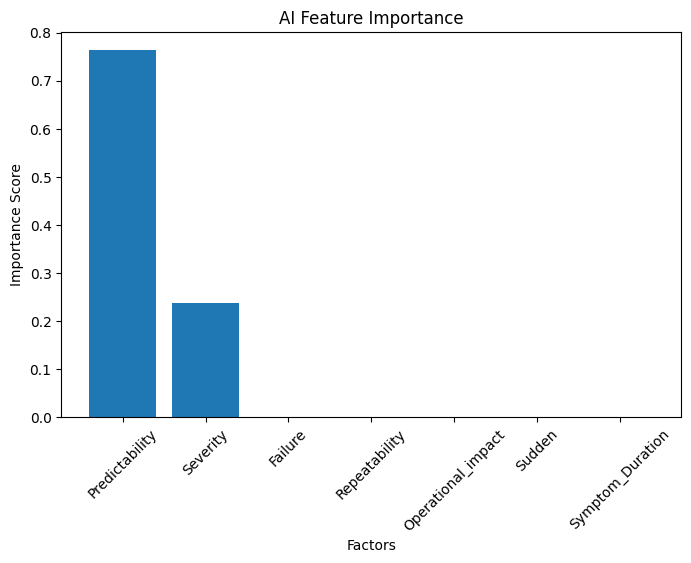

In [ ]:
import matplotlib.pyplot as plt

# رسم أهم العوامل
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('AI Feature Importance')
plt.xlabel('Factors')
plt.ylabel('Importance Score')

plt.xticks(rotation=45)

plt.show()

In [ ]:
# بيانات جهاز جديد للتجربة

new_device = [[
    1,  # Failure
    3,  # Predictability
    3,  # Repeatability
    4,  # Operational_impact
    0,  # Sudden
    3,  # Severity
    7   # Symptom_Duration
]]

# توقع الحالة
prediction = model.predict(new_device)

print("Predicted AI Status:", prediction[0])

Predicted AI Status: Critical


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# تجربة حالة متوسطة الخطورة

new_device_warning = [[
    1,  # Failure
    2,  # Predictability
    2,  # Repeatability
    3,  # Operational_impact
    0,  # Sudden
    2,  # Severity
    7   # Symptom_Duration
]]

prediction_warning = model.predict(new_device_warning)

print("Predicted AI Status:", prediction_warning[0])

Predicted AI Status: Warning


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# تجربة حالة طبيعية

new_device_normal = [[
    0,  # Failure
    1,  # Predictability
    0,  # Repeatability
    0,  # Operational_impact
    0,  # Sudden
    0,  # Severity
    0   # Symptom_Duration
]]

prediction_normal = model.predict(new_device_normal)

print("Predicted AI Status:", prediction_normal[0])

Predicted AI Status: Normal


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# تحويل التصنيفات إلى أرقام
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# إنشاء نموذج XGBoost
xgb_model = XGBClassifier()

# تدريب النموذج
xgb_model.fit(X_train, y_train)

# التنبؤ
xgb_predictions = xgb_model.predict(X_test)

# حساب الدقة
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.6666666666666666


In [ ]:
# تحويل توقعات XGBoost من أرقام إلى أسماء الحالات
xgb_pred_labels = encoder.inverse_transform(xgb_predictions)

print("XGBoost Predictions:")
print(xgb_pred_labels)

XGBoost Predictions:
['Normal' 'Normal' 'Warning']


In [ ]:
import pandas as pd

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by='Importance', ascending=False)

print(xgb_importance)

              Feature  Importance
1      Predictability    0.504125
0             Failure    0.495875
2       Repeatability    0.000000
3  Operational_impact    0.000000
4              Sudden    0.000000
5            Severity    0.000000
6    Symptom_Duration    0.000000


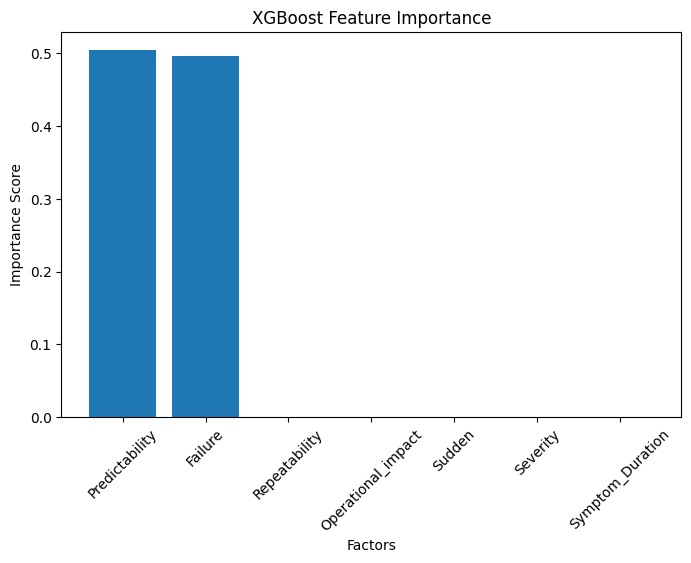

In [ ]:
import matplotlib.pyplot as plt

# رسم أهمية العوامل في XGBoost
plt.figure(figsize=(8,5))

plt.bar(
    xgb_importance['Feature'],
    xgb_importance['Importance']
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Factors')
plt.ylabel('Importance Score')

plt.xticks(rotation=45)

plt.show()